# 7 · GPU samplers and the backend

Seven samplers run on the GPU. Three of them are the *same* NUTS kernel reached three different
ways, which makes them a free cross-check on each other; the rest are GPU-batched ABC and an
emcee/SNPE pair.

**Needs:** the `[gpu]` extra, and `source "$(whisper-cbpf-env)"` **before** Python starts.

> **The trap that costs the most.** Installing `[gpu]` is not enough. Without the environment
> bootstrap, JAX silently falls back to the CPU at roughly 50x slower — no error, no warning, just a
> slow run. The first cell below checks.

> **Budgets here are illustrative, not publication-grade.** They are sized so the notebook runs in
> minutes. Before quoting any number, raise the budget until `result.info["converged"]` is `True`,
> and only compare fits that use the same `space=`.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

# float64 must be switched on BEFORE the first JAX array exists. The TDE and every supernova
# raise without it rather than returning a wrong answer.
import jax
jax.config.update("jax_enable_x64", True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__, "| x64:", wp.x64_enabled())

whisper_cbpf 0.1.1 | x64: True


## Is this actually a GPU?

Check before you time anything, and before you believe a benchmark.

In [2]:
ok, message = wp.check_gpu()
print("GPU available:", ok)
print(message)

GPU available: True
JAX sees 1 GPU device(s): [CudaDevice(id=0)]


In [3]:
import sysconfig

SITE = sysconfig.get_paths()["purelib"]


def short(value):
    """A path as it reads on any machine: relative to this install and to the repository."""
    return str(value).replace(SITE, "<site-packages>").replace(str(ROOT), "<repo>")


print("environment JAX reads at import:")
for k, v in wp.env_report().items():
    print(f"  {k:34s} {short(v)}")

environment JAX reads at import:
  CUDA_DEVICE_ORDER                  PCI_BUS_ID
  CUDA_VISIBLE_DEVICES               0
  XLA_PYTHON_CLIENT_MEM_FRACTION     0.4
  LD_LIBRARY_PATH                    <site-packages>/nvidia/cudnn/lib:<site-packages>/nvidia/cufft/lib:<site-packages>/nvidia/cuda_nvrtc/lib:<site-packages>/nvidia/cufile/lib:<site-packages>/nvidia/cusparselt/lib:<site-packages>/nvidia/cusparse/lib:<site-packages>/nvidia/nccl/lib:<site-packages>/nvidia/cuda_cupti/lib:<site-packages>/nvidia/cuda_runtime/lib:<site-packages>/nvidia/curand/lib:<site-packages>/nvidia/cusolver/lib:<site-packages>/nvidia/nvtx/lib:<site-packages>/nvidia/nvjitlink/lib:<site-packages>/nvidia/cublas/lib:<site-packages>/nvidia/nvshmem/lib:/usr/local/nvidia/lib:/usr/local/nvidia/lib64
  env_script                         <repo>/whisper_cbpf/backends/env.sh
  env_script_exists                  True
  nvidia_smi                         0, 272 MiB, 49140 MiB


In [4]:
# require_jax is what every GPU code path calls first: it returns (jax, jnp) or raises with a
# message naming the extra, rather than letting a bare ModuleNotFoundError escape.
_jax, _jnp = wp.require_jax("this notebook")
print("require_jax ->", _jax.__name__, _jnp.__name__)
print()
print("float64 enabled :", wp.x64_enabled())
print("devices to use  :", wp.gpu_list())
print("CPU workers     :", wp.n_jobs())
print("bootstrap script:", short(wp.env_script()))

require_jax -> jax jax.numpy

float64 enabled : True
devices to use  : 0
CPU workers     : 58
bootstrap script: <repo>/whisper_cbpf/backends/env.sh


## The samplers

In [5]:
gpu = [s for s in wp.list_samplers() if s.endswith("_gpu") or "jax" in s]
for s in gpu:
    print("  ", s)

   abc_gpu
   abc_smc_gpu
   emcee_jax
   nuts_gpu
   pymc_jax_gpu_parallelized
   pymc_jax_gpu_vectorized
   snpe_gpu


## The data and the model

`flare_jax` needs no filter set, so it is the cheapest thing to demonstrate every sampler against.
Notebook 06 shows the physical models; they slot into exactly the same calls.

Its shipped prior is generic: `log_amp` from -2 puts the peak at 0.14 Jy or brighter, 300 times
AT2017GFO's g-band peak, and `t0` runs to day 30. The fits below use a prior on the data's scale.

In [6]:
lc = wp.load_lightcurve(AT2017GFO, redshift=0.0098)
lc = lc.select_bands(["g"]).set_explosion_date(57982.529).select_time_window(0.0, 8.0)
if "upper_limit" in lc.colnames:
    lc = lc.where(upper_limit=False)
print(lc.n_points, "points")
print(wp.get_model("flare_jax").parameters)

# flare_jax's parameters are already logarithms, so a flat prior on each is log-uniform in the
# amplitude and the two timescales.
prior = wp.Prior({
    "log_amp":   wp.Uniform(-11.0, -5.0, name="log_amp"),     # peak 1.7e-5 .. 6.7e-3 Jy
    "log_sigma": wp.Uniform(-3.0, 2.0, name="log_sigma"),     # rise width 0.05 .. 7.4 d
    "log_tau":   wp.Uniform(-2.0, 3.0, name="log_tau"),       # decay time 0.14 .. 20 d
    "t0":        wp.Uniform(0.0, 2.0, name="t0"),             # peak within two days
})

53 points
['log_amp', 'log_sigma', 'log_tau', 't0']


## NUTS, three ways

`nuts_gpu` calls NumPyro's NUTS directly. The two `pymc_jax_gpu_*` samplers reach the *same kernel*
through PyMC's model API — `_vectorized` vmaps the chains onto one device, `_parallelized` pmaps
them across several. So all three should agree to sampling noise; if they do not, the disagreement
is in the plumbing, not the physics.

In [7]:
runs = {}
runs["nuts_gpu"] = wp.fit(lc, "flare_jax", prior=prior, sampler="nuts_gpu", space="magnitude",
                          num_warmup=300, num_samples=600, seed=0)
info = runs["nuts_gpu"].info
print(runs["nuts_gpu"])
print("divergences:", info.get("n_divergences"),
      "| max r-hat:", round(float(info.get("max_rhat") or float("nan")), 4),
      "| converged:", info.get("converged"))
for problem in info.get("convergence_problems", []):     # empty exactly when converged
    print("  -", problem)

SamplerResult(sampler='nuts_gpu', model='flare_jax', n_samples=2400, AIC=275.5, runtime=60.47s)
divergences: 58 | max r-hat: 1.0794 | converged: False
  - 58 divergent transition(s): the sampler could not follow the posterior's curvature somewhere, so the draws may be biased
  - R-hat 1.079 on 'log_amp' (must be < 1.01): the chains disagree about where the posterior is
  - smallest bulk/tail ESS 76 < 400 (100 per chain): too few effective draws for R-hat and intervals to be reliable


In [8]:
runs["pymc_vectorized"] = wp.fit(lc, "flare_jax", prior=prior, sampler="pymc_jax_gpu_vectorized",
                                 space="magnitude", num_warmup=300, num_samples=600, seed=0)
print(runs["pymc_vectorized"])

There were 124 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


SamplerResult(sampler='pymc_jax_gpu_vectorized', model='flare_jax', n_samples=2400, AIC=275.5, runtime=45.41s)


In [9]:
# _parallelized needs more than one visible device to mean anything. With one it warns rather
# than reporting a fake multi-GPU result.
try:
    runs["pymc_parallelized"] = wp.fit(lc, "flare_jax", prior=prior,
                                       sampler="pymc_jax_gpu_parallelized", space="magnitude",
                                       num_warmup=200, num_samples=400, seed=0)
    print(runs["pymc_parallelized"])
except Exception as exc:
    print(f"{type(exc).__name__}: {str(exc)[:200]}")

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


SamplerResult(sampler='pymc_jax_gpu_parallelized', model='flare_jax', n_samples=1600, AIC=275.5, runtime=93.97s)


### Do the three NUTS frontends agree?

In [10]:
nuts = {k: v for k, v in runs.items() if "nuts" in k or "pymc" in k}
params = list(next(iter(nuts.values())).summary)

print(f"{'param':14s}" + "".join(f"{k:>22s}" for k in nuts))
for p in params:
    row = "".join(f"{nuts[k].summary[p]['median']:22.5f}" if p in nuts[k].summary else f"{'-':>22s}"
                  for k in nuts)
    print(f"{p:14s}{row}")
print()
for k, v in nuts.items():
    print(f"  {k:22s} AIC {v.aic:10.3f}   divergences {v.info.get('n_divergences')!s:>4s}"
          f"   converged {v.info.get('converged')}")

param                       nuts_gpu       pymc_vectorized     pymc_parallelized
log_amp                     -7.59600              -7.62574              -7.63358
log_sigma                   -0.52663              -0.41263              -0.40621
log_tau                     -0.04327              -0.04362              -0.04333
t0                           0.19571               0.22497               0.23186

  nuts_gpu               AIC    275.509   divergences   58   converged False
  pymc_vectorized        AIC    275.510   divergences  124   converged False
  pymc_parallelized      AIC    275.510   divergences    1   converged False


## emcee, vectorised over JAX

The same ensemble sampler as the CPU `mcmc`, but the log-density is jitted and every walker is
evaluated in one batched call. No gradients needed, which makes it the fallback when a model is not
differentiable.

In [11]:
runs["emcee_jax"] = wp.fit(lc, "flare_jax", prior=prior, sampler="emcee_jax", space="magnitude",
                           nwalkers=32, nsteps=4000, burnin=500, thin=5, seed=0)
r = runs["emcee_jax"]
print(r)
print("acceptance:", round(r.info["mean_acceptance_fraction"], 3),
      "| autocorr:", round(r.info["mean_autocorr_time"], 1),
      "| converged:", r.info["converged"])
for problem in r.info.get("convergence_problems", []):
    print("  -", problem)

SamplerResult(sampler='emcee_jax', model='flare_jax', n_samples=22400, AIC=275.5, runtime=13.20s)
acceptance: 0.493 | autocorr: 60.3 | converged: True


> **`burnin` must be shorter than `nsteps`.** The default burn-in is 1000, so a short exploratory
> run needs `burnin` lowered too — otherwise the whole chain is discarded. WHISPER refuses that up
> front rather than failing later inside numpy.

In [12]:
try:
    wp.fit(lc, "flare_jax", prior=prior, sampler="emcee_jax", space="magnitude", nsteps=200, seed=0)
except ValueError as exc:
    print("ValueError:", exc)

ValueError: burnin=1000 discards the whole chain of nsteps=200. The burn-in must be shorter than the chain; raise nsteps or lower burnin.


## ABC on the GPU

Likelihood-free: propose, simulate, measure the distance, keep the closest. The simulation is what
costs, and it is exactly what batches well on a GPU.

In [13]:
runs["abc_gpu"] = wp.fit(lc, "flare_jax", prior=prior, sampler="abc_gpu", space="magnitude",
                         n_simulations=20000, quantile=0.02, seed=0)
print(runs["abc_gpu"])
print("epsilon:", runs["abc_gpu"].min_distance)

SamplerResult(sampler='abc_gpu', model='flare_jax', n_samples=400, AIC=391.8, runtime=1.77s)
epsilon: 649.7666525652292


In [14]:
runs["abc_smc_gpu"] = wp.fit(lc, "flare_jax", prior=prior, sampler="abc_smc_gpu", space="magnitude",
                             n_particles=200, n_rounds=4, seed=0)
print(runs["abc_smc_gpu"])
smc = runs["abc_smc_gpu"]
print("final epsilon   :", round(smc.info["final_epsilon"], 3))
print("total attempts  :", smc.info["total_attempts"])
print()
print("per round:")
for i, rd in enumerate(smc.info["rounds"]):
    eps = rd["epsilon"]
    print(f"  round {i}  epsilon = {eps if eps is None else round(eps, 3)}")

SamplerResult(sampler='abc_smc_gpu', model='flare_jax', n_samples=200, AIC=1872.5, runtime=9.60s)
final epsilon   : 55605.875
total attempts  : 10500

per round:
  round 0  epsilon = None
  round 1  epsilon = 351325.121
  round 2  epsilon = 112567.137
  round 3  epsilon = 55605.875


## SNPE on the GPU

`snpe_gpu` simulates on the device and hands the training set to the same sbi machinery the CPU
`snpe` uses, so the expensive half runs where it should.

In [15]:
try:
    runs["snpe_gpu"] = wp.fit(lc, "flare_jax", prior=prior, sampler="snpe_gpu", space="magnitude",
                              num_rounds=1, num_simulations=2000, num_samples=1000, seed=0)
    print(runs["snpe_gpu"])
except Exception as exc:
    print(f"{type(exc).__name__}: {str(exc)[:200]}")

 Neural network successfully converged after 307 epochs.

                    accepted. It may take a long time to collect the remaining
                    933 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


SamplerResult(sampler='snpe_gpu', model='flare_jax', n_samples=1000, AIC=2063.8, runtime=69.63s)


## Everything side by side

Same model, same data, same space. Read this as a consistency check, not a league table — the
budgets differ and each sampler is doing a different amount of work. AIC comes from each fit's best
draw: the four likelihood-based fits reach the same one, and the likelihood-free fits, at these
budgets, stop short of it.

In [16]:
print(f"{'sampler':24s} {'AIC':>13s} {'draws':>8s} {'runtime':>10s}")
for name, res in runs.items():
    print(f"{name:24s} {res.aic:13.2f} {res.n_samples:8d} {res.runtime_s:9.1f}s")

sampler                            AIC    draws    runtime
nuts_gpu                        275.51     2400      60.5s
pymc_vectorized                 275.51     2400      45.4s
pymc_parallelized               275.51     1600      94.0s
emcee_jax                       275.51    22400      13.2s
abc_gpu                         391.78      400       1.8s
abc_smc_gpu                    1872.46      200       9.6s
snpe_gpu                       2063.84     1000      69.6s


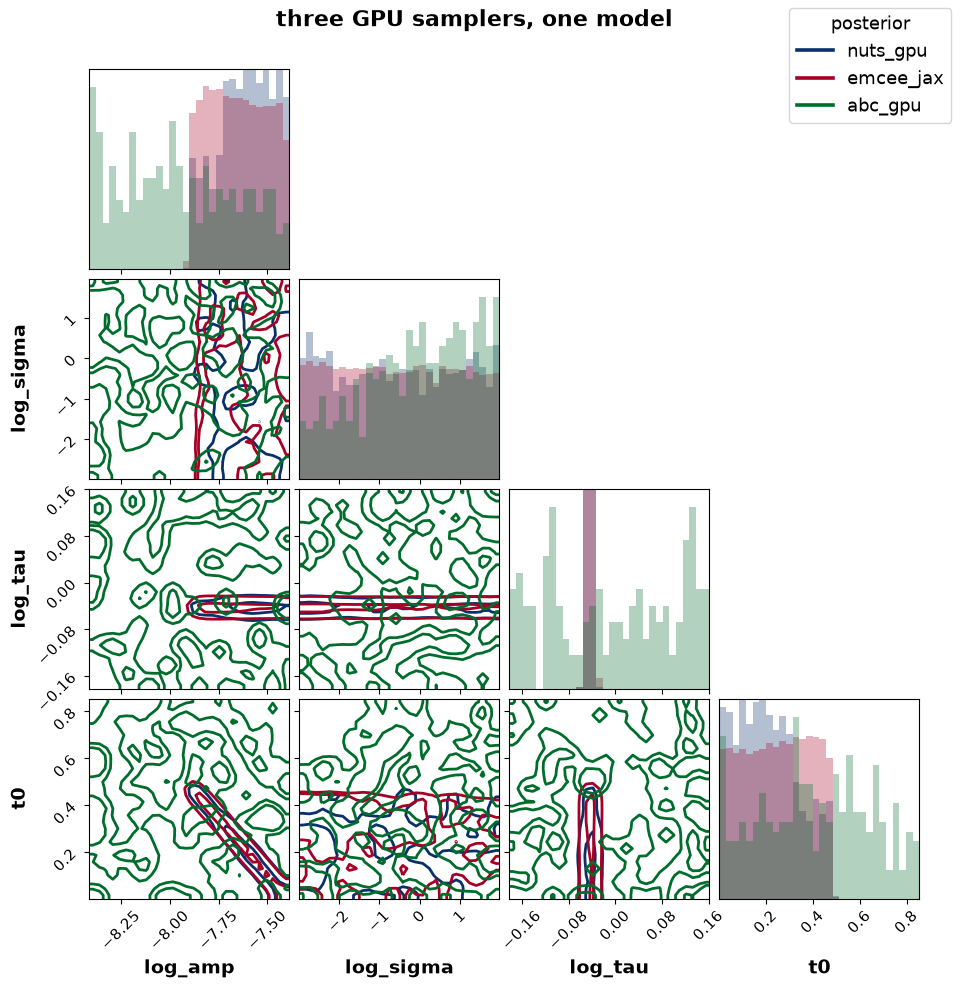

In [17]:
overlay = [runs[k] for k in ("nuts_gpu", "emcee_jax", "abc_gpu") if k in runs]
labels = [k for k in ("nuts_gpu", "emcee_jax", "abc_gpu") if k in runs]
axes = wp.plot_corner(overlay, labels=labels, title="three GPU samplers, one model")
plt.show()

## Reading `converged` before you believe a posterior

Every sampler above except SNPE is local: a chain that starts in a separate optimum of the
likelihood (the model switched off between the epochs, or a corner of the prior box) stays there,
and its draws are pooled into the posterior. So the JAX samplers start each chain at a distinct
prior draw that was scored and climbed into the best basin found (`init_strategy="prior_scan"` for
NUTS and PyMC, `init="prior_scan"` for emcee), warn before sampling when float32 cannot resolve an
MJD-scale clock, and check every fit. `result.info["converged"]` is `True` only with no divergence,
R-hat below 1.01 on every parameter and on the log-likelihood, at least 100 effective draws per
chain, no stranded, frozen or stuck chain, and no better optimum than every chain reached. When it
is `False`, `result.info["convergence_problems"]` names each check that failed.

Here the flare's kink at `t0`, where the Gaussian rise meets the exponential decay, makes NUTS
diverge, and all three NUTS frontends report it. The decay time they find still agrees with
emcee's; `log_sigma`, the width of a rise the data never saw, is set by the prior. No start can
promise the right basin, so read the problems list before you quote a number.

## Where next

* [06 · JAX physical models](06_jax_physical_models.ipynb) — fit these samplers to real physics.
* [`docs/CHOOSING.md`](../docs/CHOOSING.md) — which sampler, and which combinations cannot work.
* [`docs/GPU_SETUP.md`](../docs/GPU_SETUP.md) — CUDA, float64 and multi-GPU.